**MNIST Handwritten Digit Clasification using Deep Learning (Neural Network)**

Importing the Dependencies

In [297]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix

Loading the MNIST data from keras.datasets

In [298]:
(X_train, Y_train), (X_test, Y_test) =  mnist.load_data()

In [299]:
type(X_train)

numpy.ndarray

In [300]:
# shape of the numpy arrays
print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


Training data = 60,000 Images

Test data = 10,000 Images

Image dimension  --> 28 x 28

Grayscale Image  --> 1 channel

In [301]:
# printing the 10th image

print(X_train[10])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

In [302]:
print(X_train[10].shape)

(28, 28)


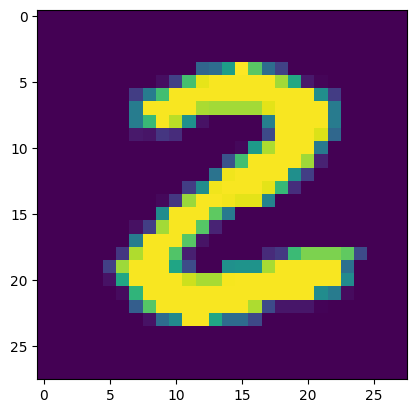

2


In [303]:
# displaying the image

plt.imshow(X_train[25])
plt.show()

# print the corresponding label
print(Y_train[25])

Image Lables

In [304]:
print(Y_train.shape, Y_test.shape)

(60000,) (10000,)


In [305]:
# unique values in Y_train
print(np.unique(Y_train))

# unique values in Y_test
print(np.unique(Y_test))

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


We can use these labels as such or we can also apply One Hot Encoding

All the images have the same dimensions in this dataset, If not, we have to resize all the images to a common dimension

In [306]:
# scaling the values

X_train = X_train/255
X_test = X_test/255

In [307]:
# printing the 10th image

print(X_train[10])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

Building the Neural Network

In [308]:
# setting up the layers of the Neural  Network

model = keras.Sequential([
                          keras.layers.Flatten(input_shape=(28,28)),
                          keras.layers.Dense(50, activation='relu'),
                          keras.layers.Dense(50, activation='relu'),
                          keras.layers.Dense(10, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [309]:
# compiling the Neural Network

model.compile(optimizer='adam',
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [310]:
# training the Neural Network

model.fit(X_train, Y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9133 - loss: 0.2995
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9589 - loss: 0.1381
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9699 - loss: 0.1005
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9765 - loss: 0.0797
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9809 - loss: 0.0649
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9835 - loss: 0.0550
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9863 - loss: 0.0462
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9881 - loss: 0.0402
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9899 - loss: 0.0341
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9906 - loss: 0.0306


Training data accuracy = 98.9%

**Accuracy on Test data:**

In [311]:
loss, accuracy = model.evaluate(X_test, Y_test)
print(accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9686 - loss: 0.1247
0.9685999751091003


Test data accuracy = 97.1%

In [312]:
print(X_test.shape)

(10000, 28, 28)


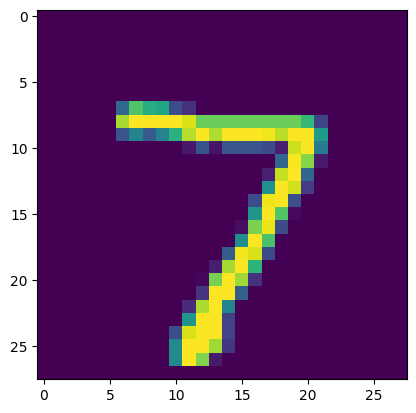

In [313]:
# first data point in X_test
plt.imshow(X_test[0])
plt.show()

In [314]:
print(Y_test[0])

7


In [315]:
Y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [316]:
print(Y_pred.shape)

(10000, 10)


In [317]:
print(Y_pred[0])

[2.5239461e-03 1.0143676e-01 2.6774380e-01 9.9145192e-01 2.4817034e-06
 1.8347520e-02 6.8831390e-08 9.9999964e-01 7.3408976e-02 6.3346356e-01]


model.predict() gives the prediction probability of each class for that data point

In [318]:
# converting the prediction probabilities to class label

label_for_first_test_image = np.argmax(Y_pred[0])
print(label_for_first_test_image)

7


In [319]:
# converting the prediction probabilities to class label for all test data points
Y_pred_labels = [np.argmax(i) for i in Y_pred]
print(Y_pred_labels)

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(5), np.int64(9), np.int64(0), np.int64(6), np.int64(9), np.int64(0), np.int64(1), np.int64(5), np.int64(9), np.int64(7), np.int64(3), np.int64(4), np.int64(9), np.int64(6), np.int64(6), np.int64(5), np.int64(4), np.int64(0), np.int64(7), np.int64(4), np.int64(0), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(4), np.int64(7), np.int64(2), np.int64(7), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(7), np.int64(4), np.int64(2), np.int64(3), np.int64(5), np.int64(1), np.int64(2), np.int64(4), np.int64(4), np.int64(6), np.int64(3), np.int64(5), np.int64(5), np.int64(6), np.int64(0), np.int64(4), np.int64(1), np.int64(9), np.int64(5), np.int64(7), np.int64(8), np.int64(5), np.int64(3), np.int64(7), np.int64(4), np.int64(6), np.int64(4), np.int64(3), np.int64(0), np.int64(7), np.int64(0), np.int64(2), np.int64(9), np.int64(1), np.int64(7), np.int64(3)

Y_test  -->  True labels

Y_pred_labels  -->  Predicted Labels

Confusin Matrix

In [320]:
conf_mat = confusion_matrix(Y_test, Y_pred_labels)

In [321]:
print(conf_mat)

tf.Tensor(
[[ 953    0    1    3    1    4    2    2    4   10]
 [   0 1123    0    4    1    1    2    1    3    0]
 [   5    3  972   16   11    0    2   14    9    0]
 [   0    0    3  992    0    3    0    1    6    5]
 [   1    0    0    1  957    3    5    2    0   13]
 [   2    0    0   22    1  851    5    2    5    4]
 [   4    3    1    1    7    9  930    1    2    0]
 [   0    3    4    3    4    0    0  997    2   15]
 [   2    0    4   14    9    2    2    4  933    4]
 [   0    2    0    9   10    4    1    5    0  978]], shape=(10, 10), dtype=int32)


Text(0.5, 47.7222222222222, 'Predicted Labels')

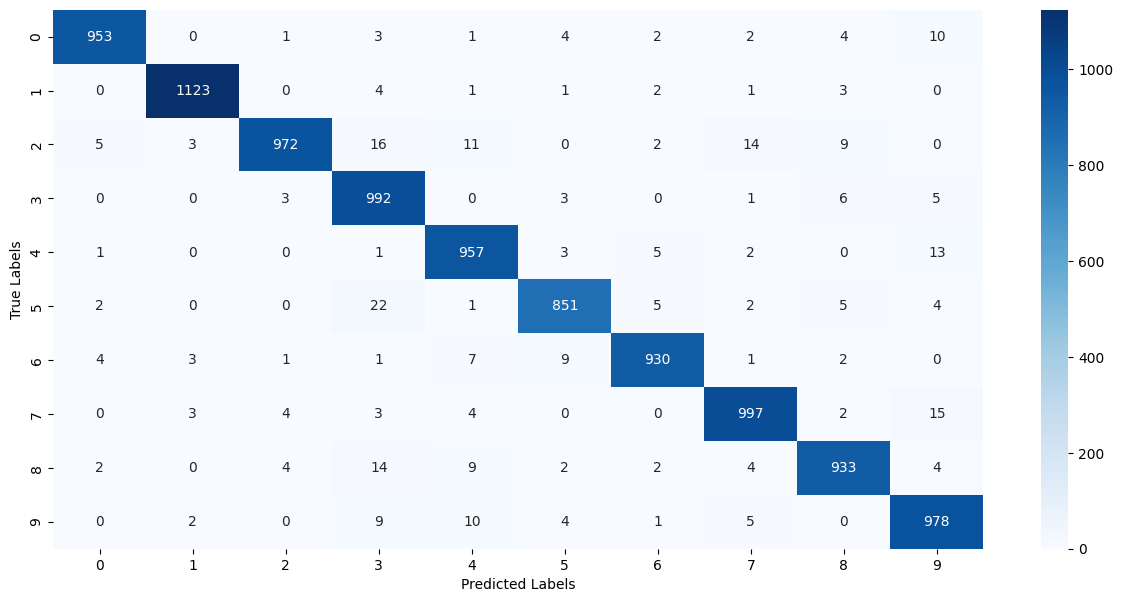

In [322]:
plt.figure(figsize=(15,7))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')

Building a Predictive System

Prediction image link: https://camo.githubusercontent.com/3d9666a8f0c5658667292b74ca19295827c2b22a0e903db283998ae213e6f6e1/68747470733a2f2f646174616d61646e6573732e6769746875622e696f2f6173736574732f696d616765732f74665f66696c655f666565642f4d4e4953545f64696769742e706e67

In [323]:
input_image_path = '/content/3-digit.PNG'

input_image = cv2.imread(input_image_path)

In [324]:
type(input_image)

numpy.ndarray

In [325]:
print(input_image)

[[[44 42 40]
  [ 0  0  0]
  [ 0  0  0]
  ...
  [ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]]

 [[44 42 40]
  [ 0  0  0]
  [ 0  0  0]
  ...
  [ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]]

 [[44 42 40]
  [ 0  0  0]
  [ 0  0  0]
  ...
  [ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]]

 ...

 [[44 42 40]
  [ 0  0  0]
  [ 0  0  0]
  ...
  [ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]]

 [[44 42 40]
  [ 0  0  0]
  [ 0  0  0]
  ...
  [ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]]

 [[44 42 40]
  [ 0  0  0]
  [ 0  0  0]
  ...
  [ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]]]


In [326]:
import os
print(os.listdir('/content'))

['.config', '3-digit.PNG', 'sample_data']


Image loaded: True


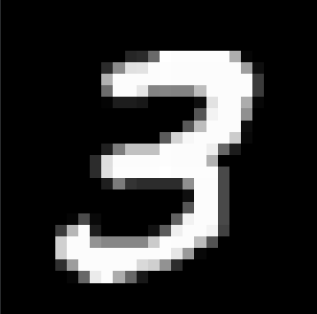

In [327]:
import cv2

img = cv2.imread('/content/3-digit.PNG')

print("Image loaded:", img is not None)

if img is not None:
    cv2_imshow(img)
else:
    print("Image not found")

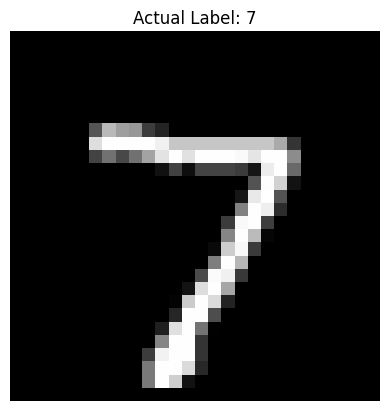

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted Digit: 7


In [328]:
import matplotlib.pyplot as plt
import numpy as np

# Display a test image from the MNIST dataset
plt.imshow(X_test[0], cmap='gray')
plt.title("Actual Label: {}".format(Y_test[0]))
plt.axis('off')
plt.show()

# Predict the digit
prediction = model.predict(X_test[0].reshape(1, 28, 28))

print("Predicted Digit:", np.argmax(prediction))

In [329]:
print("X_test exists:", 'X_test' in globals())
print("x_test exists:", 'x_test' in globals())
print("Y_test exists:", 'Y_test' in globals())
print("y_test exists:", 'y_test' in globals())

X_test exists: True
x_test exists: False
Y_test exists: True
y_test exists: False


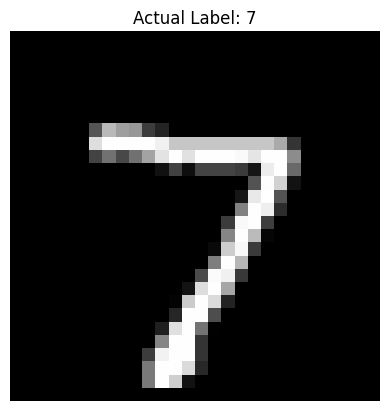

Shape: (28, 28)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Prediction Probabilities:
[[2.5239389e-03 1.0143676e-01 2.6774395e-01 9.9145192e-01 2.4817011e-06
  1.8347541e-02 6.8831270e-08 9.9999964e-01 7.3408745e-02 6.3346314e-01]]
Predicted Digit: 7
Actual Digit: 7


In [330]:
import matplotlib.pyplot as plt
import numpy as np

# Show the first test image
plt.imshow(X_test[0], cmap='gray')
plt.title("Actual Label: {}".format(Y_test[0]))
plt.axis('off')
plt.show()

# Check the shape
print("Shape:", X_test[0].shape)

# Make prediction
prediction = model.predict(X_test[0].reshape(1, 28, 28))

print("Prediction Probabilities:")
print(prediction)

print("Predicted Digit:", np.argmax(prediction))
print("Actual Digit:", Y_test[0])

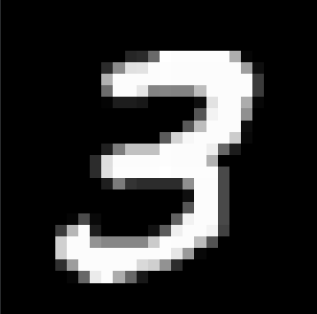

In [331]:
cv2_imshow(input_image)

In [332]:
input_image.shape

(314, 317, 3)

In [333]:
grayscale = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)

In [334]:
grayscale.shape

(314, 317)

In [335]:
input_image_resize = cv2.resize(grayscale, (28, 28))

In [336]:
input_image_resize.shape

(28, 28)

In [337]:
cv2_imshow(input_image_resize)

In [338]:
input_image_resize = input_image_resize/255

In [339]:
type(input_image_resize)

numpy.ndarray

In [340]:
image_reshaped = np.reshape(input_image_resize, [1,28,28])

In [341]:
input_prediction = model.predict(image_reshaped)
print(input_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
[[9.7974190e-13 5.1505128e-10 2.9604151e-05 1.0000000e+00 4.7287334e-15
  8.0472594e-03 2.0792093e-21 1.2766080e-09 3.1199035e-01 9.7960806e-01]]


In [342]:
input_pred_label = np.argmax(input_prediction)

In [343]:
print(input_pred_label)

3


**Predictive System**

Path of the image to be predicted: /content/3-digit.PNG


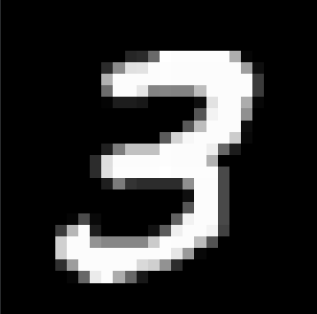

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
The Handwritten Digit is recognised as  3


In [344]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

grayscale = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)

input_image_resize = cv2.resize(grayscale, (28, 28))

input_image_resize = input_image_resize/255

image_reshaped = np.reshape(input_image_resize, [1,28,28])

input_prediction = model.predict(image_reshaped)

input_pred_label = np.argmax(input_prediction)

print('The Handwritten Digit is recognised as ', input_pred_label)